### **The "Holy Trinity" Challenge: The Real Estate & Forex Sync**

In [1]:
import pandas as pd
import io

# The raw data you provided
raw_data = """Date,Asset,Type,Amount,Status
2026-04-01,XAUUSD,Trade,150.50,Closed
2026-04-02,ZAMARI_HILL,Land,-5000.00,Pending
2026-04-03,BTCUSD,Trade,-200.00,Closed
2026-04-05,XAUUSD,Trade,450.00,Closed
2026-04-07,ETHUSD,Trade,120.25,Closed
2026-04-10,CRIBNGO_DEV,App_Dev,-1200.00,Closed
2026-04-12,XAUUSD,Trade,-50.00,Closed
2026-04-15,BTCUSD,Trade,800.00,Closed"""

# Create the file on your device
with open('market_data.csv', 'w') as f:
    f.write(raw_data)

print("File 'market_data.csv' created successfully!")


File 'market_data.csv' created successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('market_data.csv')

### **Step 1: NumPy & The Math Grad Brain**

In [4]:
df['Amount']

0     150.50
1   -5000.00
2    -200.00
3     450.00
4     120.25
5   -1200.00
6     -50.00
7     800.00
Name: Amount, dtype: float64

In [5]:
trade_amount = df['Amount'][lambda x: x> -1000]

sharpe_ratio = trade_amount.mean() / trade_amount.std()

sharpe_ratio

np.float64(0.5860642676656483)

### **Step 2: Pandas Data Surgery**

In [6]:
df['Date']

0    2026-04-01
1    2026-04-02
2    2026-04-03
3    2026-04-05
4    2026-04-07
5    2026-04-10
6    2026-04-12
7    2026-04-15
Name: Date, dtype: object

In [15]:
# pd.to_datetime(df['Date'])
# Correction - asign it!
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
new_df = df.copy()
new_df['Amount'] = df['Amount'][lambda x: x> -1000]
trades_only = new_df.dropna()

In [9]:
trades_only

,Date,Asset,Type,Amount,Status
0,2026-04-01,XAUUSD,Trade,150.50,Closed
2,2026-04-03,BTCUSD,Trade,-200.00,Closed
3,2026-04-05,XAUUSD,Trade,450.00,Closed
4,2026-04-07,ETHUSD,Trade,120.25,Closed
6,2026-04-12,XAUUSD,Trade,-50.00,Closed
7,2026-04-15,BTCUSD,Trade,800.00,Closed


In [16]:
# trades_only['running_bal'] = trades_only['Amount'].cumsum()

# Correction -  Proper Categorical Filtering
trades_only = df[df['Type'] == 'Trade'].copy()
trades_only['running_bal'] = trades_only['Amount'].cumsum()


In [17]:
trades_only

,Date,Asset,Type,Amount,Status,running_bal
0,2026-04-01,XAUUSD,Trade,150.50,Closed,150.50
2,2026-04-03,BTCUSD,Trade,-200.00,Closed,-49.50
3,2026-04-05,XAUUSD,Trade,450.00,Closed,400.50
4,2026-04-07,ETHUSD,Trade,120.25,Closed,520.75
6,2026-04-12,XAUUSD,Trade,-50.00,Closed,470.75
7,2026-04-15,BTCUSD,Trade,800.00,Closed,1270.75


### **Step 3: The Matplotlib "Object-Oriented" Plot**

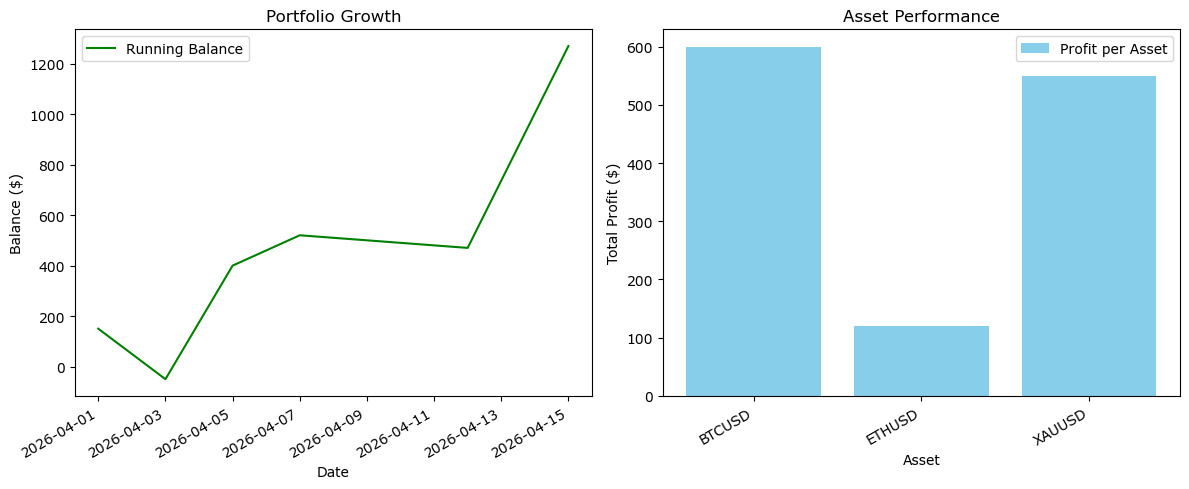

In [22]:
# Correction
import matplotlib.pyplot as plt

# 1. Correct Subplot Initialization
# Note the parentheses around (ax1, ax2) to 'unpack' the two plots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# 2. Plotting the Line Chart (ax1)
ax1.plot(trades_only['Date'], trades_only['running_bal'], color='green', label='Running Balance')

# Formatting the dates so they don't overlap
fig.autofmt_xdate() 

ax1.set_title('Portfolio Growth')
ax1.set_xlabel('Date')
ax1.set_ylabel('Balance ($)')
ax1.legend()

# 3. Plotting the Bar Chart (ax2)
# We group the data first
profit_asset = trades_only.groupby('Asset')['Amount'].sum()

# Correct Syntax: ax.bar(x_labels, y_heights)
ax2.bar(profit_asset.index, profit_asset.values, color='skyblue', label='Profit per Asset')

ax2.set_title('Asset Performance')
ax2.set_xlabel('Asset')
ax2.set_ylabel('Total Profit ($)')
ax2.legend()

# 4. Final Polish
plt.tight_layout()
plt.show()


### **Step 4: The Export**

In [24]:
# trades_only = pd.to_excel('trades_only.xlsx')

# Correction 
trades_only.to_excel('trades_only.xlsx', index=False)

ModuleNotFoundError: No module named 'openpyxl'

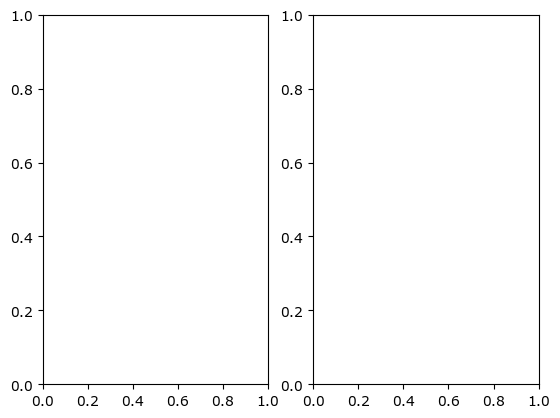

In [12]:
fig,(ax1,ax2) = plt.subplots(1,2)

In [13]:
ax1.plot(trades_only['Date'], trades_only['running_bal'],
         label=['Date','Running Balance'])

ax1.set_title('Date vs Running Balance')
ax1.set_xlabel('Date')
ax1.set_ylabel('Running Balance')

ax1.legend()
fig.tight_layout()

plt.show()

/private/var/mobile/Containers/Data/Application/53C3D0BE-44DA-43AE-86DB-7D9A43657AB6/tmp/ipykernel_5624/4130109938.py:1: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax1.plot(trades_only['Date'], trades_only['running_bal'],


In [19]:
#profit_asset = trades_only.groupby(['Asset'])[['Amount']].sum()
#pairs = profit_asset.iloc[0:,0:0]

# Correction - Correct Bar Chart Syntax (X then Y)
profit_asset = trades_only.groupby('Asset')['Amount'].sum()
ax2.bar(profit_asset.index, profit_asset.values) # index is Asset, values is Amount
ax2.bar(profit_asset['Amount'],pairs,
         label=['Asset','Total Profit'])

ax2.set_title('Asset vs Total Profit')
ax2.set_xlabel('Asset')
ax2.set_ylabel('Total Profit')

ax2.legend()

plt.show()

KeyError: 'Amount'

# CORRECTION

In [ ]:
Sequential Grading
Step 1: NumPy & The Sharpe Ratio
• The Logic: You used a lambda function lambda x: x > -1000 to filter the data. While creative, it’s a bit "dangerous" because if a trade actually lost more than $1,000, your math would ignore it!
• The Math: You calculated mean / std correctly.
• The Grade: 8/10.
• The Direct Truth: You filtered by value, not by the "Type" column. If you had a real estate expense of $-900, it would have stayed in your "Trade" calculation.
Step 2: Pandas Data Surgery
• Task 1 (Datetime): You called pd.to_datetime(df['Date']) but did not assign it back. The column stayed as a string (Object). This is why your x-axis in the plot probably looked messy.
• Task 2 (Filter): You used dropna() after a lambda filter. It worked, but it's a "roundabout" way of doing it.
• Task 3 (Cumsum): Correct! You got the SettingWithCopyWarning—every Pandas beginner's first rite of passage.
• The Grade: 7/10.
Step 3: Matplotlib Object-Oriented Plot
• The Setup: fig, (ax1, ax2) was perfect.
• The Crash (ValueError): You hit a wall here. In ax2.bar(profit_asset['Amount'], pairs), you swapped the X and Y. Bars need labels (Assets) first, then the heights (Amount). Also, your pairs variable was an empty slice [0:0].
• The Logic: You forgot autofmt_xdate() on the fig level, and the label=['Date','Running Balance'] inside ax1.plot is why you got that deprecation warning.
• The Grade: 4/10. (You understood the structure, but the execution was "buggy").
Step 4: The Export
• AttributeError: You tried pd.to_excel().
• The Direct Truth: to_excel is a method of the DataFrame, not a function of the library. It should be trades_only.to_excel().
• The Grade: 2/10.
General Feedback & Score
Total Score: 21/40 (52.5%)